# Оценка методов генерации упражнений

**Сравниваются 5 методов:**

| Метод | Тип | Описание |
|-------|-----|----------|
| **Fill-in-the-Blanks** | Baseline (шаблонный) | Пропуск в предложении + дистракторы по POS |
| **Sentence Reconstruction** | Baseline (шаблонный) | Перемешивание токенов предложения |
| **Qwen2.5-3B + LoRA** | Fine-tuned LLM | Генерация полных упражнений |
| **SmolLM3-3B + LoRA** | Fine-tuned LLM | Генерация полных упражнений |
| **Phi-3.5-mini + LoRA** | Fine-tuned LLM (retrained, seq=2560) | Генерация полных упражнений |

### Загрузить в Colab:
- `val.jsonl`, `val_meta.json`
- `all_predictions.json` — предикты Qwen + SmolLM (50 val)
- `adapters/phi3.5-mini/` — новые адаптеры Phi
- Датасет EXPECT (клонируется автоматически)

## 1. Установка

In [1]:
!pip install -q     transformers>=4.51.0     peft>=0.13.2     accelerate>=1.5.0     datasets     bert-score     sentencepiece     protobuf     spacy

!python -m spacy download en_core_web_sm -q

print("✓ Установлено")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf 25.4.0 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 23.0.1 which is incompatible.
pylibcudf 25.4.0 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 23.0.1 which is incompatible.
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
✓ Установлено


## 2. Импорты

In [2]:
import os, json, gc, shutil, random, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from datetime import datetime
from tqdm import tqdm
from typing import Dict, List, Optional
from collections import defaultdict, Counter
from dataclasses import dataclass

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
import warnings
warnings.filterwarnings("ignore")

from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
import spacy

nlp = spacy.load("en_core_web_sm")

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    props = torch.cuda.get_device_properties(0)
    print(f"VRAM:    {props.total_memory / 1e9:.1f} GB")

PyTorch: 2.8.0a0+5228986c39.nv25.06
CUDA: True
GPU: NVIDIA A40
VRAM:    47.7 GB


## 3. Загрузка файлов

In [7]:
!git clone https://github.com/lorafei/Explainable_GEC.git

Cloning into 'Explainable_GEC'...
remote: Enumerating objects: 65, done.
remote: Counting objects: 100% (65/65), done.
remote: Compressing objects: 100% (49/49), done.
remote: Total 65 (delta 14), reused 65 (delta 14), pack-reused 0 (from 0)
Receiving objects: 100% (65/65), 5.44 MiB | 12.24 MiB/s, done.
Resolving deltas: 100% (14/14), done.


In [8]:
!ls

'=0.13.2'  '=4.51.0'	      adapters	 eval_300.ipynb
'=1.5.0'    Explainable_GEC   data


In [16]:
for f in ["val.jsonl", "val_meta.json", "all_predictions.json"]:
    exists = os.path.exists(f"data/{f}")
    print(f"  {'✓' if exists else '✗'} {f}")

phi_ok = os.path.isdir("adapters/phi3.5-mini")
print(f"  {'✓' if phi_ok else '✗'} adapters/phi3.5-mini/")

expect_ok = os.path.exists("Explainable_GEC/data/json/train.json")
print(f"  {'✓' if expect_ok else '✗'} EXPECT dataset")

  ✓ val.jsonl
  ✓ val_meta.json
  ✓ all_predictions.json
  ✓ adapters/phi3.5-mini/
  ✓ EXPECT dataset


## 4. Загрузка данных

In [17]:
val_records = []
with open("data/dataset/val.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        val_records.append(json.loads(line))

with open("data/dataset/val_meta.json", "r", encoding="utf-8") as f:
    val_meta = json.load(f)

val_records_300 = val_records        # все 300
val_meta_300 = val_meta              # все 300
references_300 = [r["messages"][2]["content"] for r in val_records_300]

print(f"Val для оценки: {len(val_records_300)}")

with open("data/predictions/all_predictions.json", "r", encoding="utf-8") as f:
    all_predictions = json.load(f)

for name, preds in all_predictions.items():
    print(f"  {name}: {len(preds)} предиктов")

Val для оценки: 300
  qwen2.5-3b: 50 предиктов
  smollm3-3b: 50 предиктов
  phi3.5-mini: 50 предиктов


In [18]:
expect_rows = []
with open("Explainable_GEC/data/json/train.json", "r", encoding="utf-8") as f:
    for line in f:
        expect_rows.append(json.loads(line))

expect_df = pd.DataFrame(expect_rows)

def detokenize(tokens) -> str:
    if isinstance(tokens, list):
        token_list = tokens
    elif isinstance(tokens, str):
        token_list = tokens.split(',')
    else:
        return str(tokens)
    no_space_before = {'.', ',', ':', ';', '!', '?', ')', ']', '}', "n't"}
    result = []
    for i, token in enumerate(token_list):
        token = token.strip()
        if token == '[NONE]' or not token:
            continue
        if i == 0 or token in no_space_before or token.startswith("'"):
            result.append(token)
        else:
            result.append(' ' + token)
    return ''.join(result)

expect_df['source_text'] = expect_df['source'].apply(detokenize)
expect_df['target_text'] = expect_df['target'].apply(detokenize)

print(f"EXPECT записей: {len(expect_df)}")

EXPECT записей: 15187


---
## Часть A: Бейзлайны (шаблонные методы)

### A1. Fill-in-the-Blanks
Извлекаем слово из correction_index, создаём пропуск, генерируем дистракторы через spaCy POS-теги.

In [39]:
def get_pos_spacy(word: str) -> str:
    if not word or word in ['[NONE]', 'None', '', None]:
        return 'OTHER'
    try:
        doc = nlp(word)
        if len(doc) == 0:
            return 'OTHER'
        pos_mapping = {
            'ADP': 'PREP', 'DET': 'ART', 'PRON': 'PRON', 'AUX': 'AUX',
            'VERB': 'VERB', 'NOUN': 'NOUN', 'ADJ': 'ADJ', 'ADV': 'ADV',
            'PART': 'PART', 'NUM': 'NUM',
        }
        return pos_mapping.get(doc[0].pos_, 'OTHER')
    except:
        return 'OTHER'


def analyze_correction_type(row):
    source_tokens = row['source'] if isinstance(row['source'], list) else row['source'].split(',')
    target_tokens = row['target'] if isinstance(row['target'], list) else row['target'].split(',')
    source_clean = [t for t in source_tokens if t.strip() and t != '[NONE]']
    if len(target_tokens) > len(source_clean):
        return "insertion"
    elif len(target_tokens) < len(source_clean):
        return "deletion"
    return "replacement"


def extract_blank_word(row):
    correction_idx = row['correction_index']
    if isinstance(correction_idx, str):
        correction_idx = [int(i) for i in correction_idx.split(',') if i.strip()]
    elif isinstance(correction_idx, list):
        correction_idx = [int(i) for i in correction_idx if str(i).strip()]

    target_tokens = row['target'] if isinstance(row['target'], list) else row['target'].split(',')
    source_tokens = row['source'] if isinstance(row['source'], list) else row['source'].split(',')
    target_clean = [t.strip() for t in target_tokens if t.strip() and t != '[NONE]']
    source_clean = [t.strip() for t in source_tokens if t.strip() and t != '[NONE]']
    sep_len = len(target_clean) + 1

    target_indices = [i for i in correction_idx if i < sep_len]

    if not target_indices or not target_clean:
        return None

    idx = target_indices[0]
    if idx >= len(target_clean):
        return None

    blank_word = target_clean[idx]
    source_indices = [i - sep_len for i in correction_idx if i >= sep_len]
    wrong = source_clean[source_indices[0]] if source_indices and source_indices[0] < len(source_clean) else None

    return {
        'blank_word': blank_word,
        'blank_position': idx,
        'wrong_answer': wrong,
        'suitable': len(blank_word) > 1 and blank_word not in ['[NONE]', '.', ',']
    }


expect_df['correction_type'] = expect_df.apply(analyze_correction_type, axis=1)
blank_info = expect_df.apply(extract_blank_word, axis=1)
expect_df['blank_info'] = blank_info
expect_df['blank_word'] = blank_info.apply(lambda x: x['blank_word'] if x else None)
expect_df['blank_position'] = blank_info.apply(lambda x: x['blank_position'] if x else None)
expect_df['wrong_answer'] = blank_info.apply(lambda x: x['wrong_answer'] if x else None)
expect_df['is_suitable'] = blank_info.apply(lambda x: x['suitable'] if x else False)

print(f"Пригодно для FiB: {expect_df['is_suitable'].sum()} / {len(expect_df)}")

spacy_pool = defaultdict(lambda: defaultdict(list))
for _, row in expect_df.iterrows():
    wa = row.get('wrong_answer')
    if wa and wa not in ['[NONE]', 'None', '', None]:
        pos = get_pos_spacy(wa)
        et = row['error_type']
        if wa not in spacy_pool[et][pos]:
            spacy_pool[et][pos].append(wa)

print(f"POS pool построен: {sum(len(v) for d in spacy_pool.values() for v in d.values())} слов")

Пригодно для FiB: 14721 / 15187
POS pool построен: 6354 слов


In [40]:
def generate_fib_exercise(row, pool):
    if not row.get('is_suitable', False):
        return None

    blank_pos = row.get('blank_position')
    if blank_pos is None or (isinstance(blank_pos, float) and np.isnan(blank_pos)):
        return None
    blank_pos = int(blank_pos)

    target_tokens = row['target'] if isinstance(row['target'], list) else row['target'].split(',')
    target_clean = [t.strip() for t in target_tokens if t.strip() and t != '[NONE]']
    if blank_pos >= len(target_clean):
        return None

    template_tokens = target_clean.copy()
    template_tokens[blank_pos] = '_____'
    template = detokenize(template_tokens)

    correct = row['blank_word']
    correct_pos = get_pos_spacy(correct)
    error_type = row['error_type']

    distractors = set()
    wa = row.get('wrong_answer')
    if wa and wa not in ['[NONE]', 'None', '', None] and get_pos_spacy(wa) == correct_pos:
        distractors.add(wa)

    if error_type in pool and correct_pos in pool[error_type]:
        candidates = [w for w in pool[error_type][correct_pos] if w != correct]
        distractors.update(random.sample(candidates, min(3, len(candidates))))

    distractors = [d for d in distractors if d != correct][:3]

    if len(distractors) < 2:
        return None

    options = [correct] + distractors
    random.shuffle(options)

    return {
        "target_error_category": error_type,
        "corrected_sentence": row['target_text'],
        "task": {
            "type": "fill_in_the_blank",
            "instruction_en": "Fill in the blank with the correct word.",
            "content_en": {
                "context_text": None,
                "items": [{
                    "question_en": template,
                    "options_en": options,
                    "student_answer_en": correct,
                }],
                "word_bank": None,
            }
        }
    }

fib_predictions = []
fib_matched = 0

for meta in val_meta_300:
    source = meta.get("source", "")
    matches = expect_df[expect_df['source_text'] == source]

    if len(matches) > 0:
        row = matches.iloc[0]
        exercise = generate_fib_exercise(row, spacy_pool)
        if exercise:
            fib_predictions.append(json.dumps(exercise, ensure_ascii=False))
            fib_matched += 1
            continue

    fib_predictions.append("{}")

print(f"FiB: сгенерировано {fib_matched} / {len(val_meta_300)} упражнений")
all_predictions["baseline_fib"] = fib_predictions

FiB: сгенерировано 285 / 300 упражнений


### A2. Sentence Reconstruction

In [41]:
def generate_reconstruction_exercise(row, difficulty='medium'):
    target_tokens = row['target'] if isinstance(row['target'], list) else row['target'].split(',')
    tokens = [t.strip() for t in target_tokens if t.strip() and t != '[NONE]']

    if len(tokens) < 4 or len(tokens) > 20:
        return None

    shuffled = tokens.copy()
    if difficulty == 'easy' and len(shuffled) > 2:
        middle = shuffled[1:-1]
        random.shuffle(middle)
        shuffled = [shuffled[0]] + middle + [shuffled[-1]]
    else:
        random.shuffle(shuffled)

    return {
        "target_error_category": row.get('error_type', 'Unknown'),
        "corrected_sentence": row.get('target_text', detokenize(tokens)),
        "task": {
            "type": "sentence_reconstruction",
            "instruction_en": "Rearrange the words to form a correct sentence.",
            "content_en": {
                "context_text": None,
                "items": [{
                    "question_en": " | ".join(shuffled),
                    "options_en": None,
                    "student_answer_en": detokenize(tokens),
                }],
                "word_bank": shuffled,
            }
        }
    }

recon_predictions = []
recon_matched = 0

for meta in val_meta_300:
    source = meta.get("source", "")
    matches = expect_df[expect_df['source_text'] == source]

    if len(matches) > 0:
        row = matches.iloc[0]
        exercise = generate_reconstruction_exercise(row)
        if exercise:
            recon_predictions.append(json.dumps(exercise, ensure_ascii=False))
            recon_matched += 1
            continue

    recon_predictions.append("{}")

print(f"Reconstruction: сгенерировано {recon_matched} / {len(val_meta_300)} упражнений")
all_predictions["baseline_recon"] = recon_predictions

Reconstruction: сгенерировано 117 / 300 упражнений


In [42]:
with open("all_predictions_300.json", "w", encoding="utf-8") as f:
    json.dump(all_predictions, f, ensure_ascii=False, indent=2)
print(f"✓ Сохранено: { {k: len(v) for k,v in all_predictions.items()} }")

✓ Сохранено: {'qwen2.5-3b': 300, 'smollm3-3b': 300, 'phi3.5-mini': 300, 'baseline_fib': 300, 'baseline_recon': 300}


---
## Часть B: Инференсы

In [22]:
import os
from huggingface_hub import login
login(token=os.environ["HF_TOKEN"])

In [23]:
MODELS_INF = {
    "qwen2.5-3b":  "Qwen/Qwen2.5-3B-Instruct",
    "smollm3-3b":  "HuggingFaceTB/SmolLM3-3B",
    "phi3.5-mini":  "microsoft/Phi-3.5-mini-instruct",
}

ADAPTERS_INF = {}
for name in MODELS_INF:
    path = f"adapters/{name}"
    if os.path.isdir(path):
        ADAPTERS_INF[name] = path
        print(f"  ✓ {name}")
    else:
        print(f"  ✗ {name}")

HF_CACHE = os.path.expanduser("~/.cache/huggingface/hub")

SAVE_PATH = "all_predictions_300.json"

# Загружаем старые предикты (50 шт) как базу
if os.path.exists(SAVE_PATH):
    with open(SAVE_PATH) as f:
        all_predictions = json.load(f)
elif os.path.exists("data/predictions/all_predictions_v2.json"):
    with open("data/predictions/all_predictions_v2.json") as f:
        all_predictions = json.load(f)
else:
    all_predictions = {}

print(f"Стартовые предикты: { {k: len(v) for k,v in all_predictions.items()} }")

def run_inference(name, base_name):
    # ── Resume: пропускаем уже готовые ────────────────────
    existing = all_predictions.get(name, [])
    start_idx = len(existing)
    total = len(val_records_300)

    if start_idx >= total:
        print(f"  ✓ {name}: уже готово ({start_idx}/{total}), пропускаю")
        return

    print(f"  ⟳ Resume с {start_idx}/{total}")

    if os.path.exists(HF_CACHE):
        shutil.rmtree(HF_CACHE)

    trust = False if "phi" in name.lower() else True
    extra = {"attn_implementation": "eager"} if not trust else {}

    tokenizer = AutoTokenizer.from_pretrained(ADAPTERS_INF[name], trust_remote_code=trust)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    base_model = AutoModelForCausalLM.from_pretrained(
        base_name, device_map="auto", trust_remote_code=trust,
        torch_dtype=torch.float16, **extra,
    )
    model = PeftModel.from_pretrained(base_model, ADAPTERS_INF[name])
    model.eval()

    predictions = list(existing)  # копируем уже готовые
    remaining = val_records_300[start_idx:]

    for rec in tqdm(remaining, desc=f"  {name}", unit="ex", initial=start_idx, total=total):
        messages = rec["messages"][:2]
        prompt = tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True
        )
        inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=2560)
        inputs = {k: v.to(model.device) for k, v in inputs.items()}

        with torch.no_grad():
            output_ids = model.generate(
                **inputs, max_new_tokens=2048, do_sample=False,
                temperature=1.0, pad_token_id=tokenizer.pad_token_id,
            )
        gen_ids = output_ids[0][inputs["input_ids"].shape[1]:]
        predictions.append(tokenizer.decode(gen_ids, skip_special_tokens=True).strip())

        # Сохраняем каждые 25 примеров
        if len(predictions) % 25 == 0:
            all_predictions[name] = predictions
            with open(SAVE_PATH, "w", encoding="utf-8") as f:
                json.dump(all_predictions, f, ensure_ascii=False, indent=2)

    all_predictions[name] = predictions
    with open(SAVE_PATH, "w", encoding="utf-8") as f:
        json.dump(all_predictions, f, ensure_ascii=False, indent=2)

    del model, base_model, tokenizer
    gc.collect(); torch.cuda.empty_cache()

    print(f"  ✓ {len(predictions)} предсказаний сохранено")

  ✓ qwen2.5-3b
  ✓ smollm3-3b
  ✓ phi3.5-mini
Стартовые предикты: {'qwen2.5-3b': 50, 'smollm3-3b': 50, 'phi3.5-mini': 50, 'baseline_fib': 50, 'baseline_recon': 50}


In [24]:
print("=" * 50)
print("  Инференс: qwen2.5-3b")
print("=" * 50)
run_inference("qwen2.5-3b", MODELS_INF["qwen2.5-3b"])

  Инференс: qwen2.5-3b
  ⟳ Resume с 50/300


`torch_dtype` is deprecated! Use `dtype` instead!
  qwen2.5-3b: 100%|██████████| 300/300 [2:57:23<00:00, 42.57s/ex]  


  ✓ 300 предсказаний сохранено


In [25]:
print("=" * 50)
print("  Инференс: smollm3-3b")
print("=" * 50)
run_inference("smollm3-3b", MODELS_INF["smollm3-3b"])

  Инференс: smollm3-3b
  ⟳ Resume с 50/300


  smollm3-3b: 100%|██████████| 300/300 [3:07:17<00:00, 44.95s/ex]  


  ✓ 300 предсказаний сохранено


In [26]:
print("=" * 50)
print("  Инференс: phi3.5-mini")
print("=" * 50)
run_inference("phi3.5-mini", MODELS_INF["phi3.5-mini"])

  Инференс: phi3.5-mini
  ⟳ Resume с 50/300


This model config has set a `rope_parameters['original_max_position_embeddings']` field, to be used together with `max_position_embeddings` to determine a scaling factor. Please set the `factor` field of `rope_parameters`with this ratio instead -- we recommend the use of this field over `original_max_position_embeddings`, as it is compatible with most model architectures.
  phi3.5-mini: 100%|██████████| 300/300 [1:15:23<00:00, 18.09s/ex]


  ✓ 300 предсказаний сохранено


---
## Часть C: Метрики

**Для LLM-моделей:** BERTScore, Perplexity, Task-Relevance  
**Для бейзлайнов:** Task-Relevance (BERTScore и Perplexity неприменимы — другой формат генерации)

In [27]:
from bert_score import score as bert_score_fn

LLM_MODELS = ["qwen2.5-3b", "smollm3-3b", "phi3.5-mini"]
BASELINE_MODELS = ["baseline_fib", "baseline_recon"]

def compute_bertscore(predictions, references, chunk_size=3000):
    f1_scores = []
    for pred, ref in zip(predictions, references):
        pred_chunks = [pred[i:i+chunk_size] for i in range(0, max(len(pred), 1), chunk_size)]
        ref_chunks  = [ref[i:i+chunk_size] for i in range(0, max(len(ref), 1), chunk_size)]
        n = min(len(pred_chunks), len(ref_chunks))
        if n == 0:
            continue
        P, R, F1 = bert_score_fn(
            pred_chunks[:n], ref_chunks[:n],
            model_type="distilbert-base-uncased",
            lang="en", verbose=False, batch_size=8,
        )
        f1_scores.append(F1.mean().item())
    f1_arr = np.array(f1_scores)
    return {"f1": f1_arr.mean(), "f1_std": f1_arr.std()}

bertscore_results = {}
for name in LLM_MODELS:
    if name not in all_predictions:
        continue
    print(f"BERTScore для {name}...")
    bertscore_results[name] = compute_bertscore(all_predictions[name], references_300)
    print(f"  F1 = {bertscore_results[name]['f1']:.4f} ± {bertscore_results[name]['f1_std']:.4f}")

BERTScore для qwen2.5-3b...


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 2635.74it/s]
DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1918.36it/s]
DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:c

  F1 = 0.9085 ± 0.0333
BERTScore для smollm3-3b...


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 2313.37it/s]
DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 100/100 [00:00<00:00, 4616.84it/s]
DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:c

  F1 = 0.9089 ± 0.0333
BERTScore для phi3.5-mini...


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1731.18it/s]
DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 100/100 [00:00<00:00, 5457.00it/s]
DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:c

  F1 = 0.8806 ± 0.0230


In [28]:
MODELS_BASE = {
    "qwen2.5-3b":  "Qwen/Qwen2.5-3B-Instruct",
    "smollm3-3b":  "HuggingFaceTB/SmolLM3-3B",
    "phi3.5-mini":  "microsoft/Phi-3.5-mini-instruct",
}

ADAPTER_DIRS = {}
for name in ["qwen2.5-3b", "smollm3-3b", "phi3.5-mini"]:
    path = f"adapters/{name}"
    if os.path.isdir(path):
        ADAPTER_DIRS[name] = path

HF_CACHE = os.path.expanduser("~/.cache/huggingface/hub")

def compute_perplexity(base_model_name, adapter_dir, name, val_records):
    trust = False if "phi" in name.lower() else True
    extra = {"attn_implementation": "eager"} if not trust else {}

    tokenizer = AutoTokenizer.from_pretrained(adapter_dir, trust_remote_code=trust)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    base_model = AutoModelForCausalLM.from_pretrained(
        base_model_name, device_map={"": 0}, trust_remote_code=trust,
        torch_dtype=torch.float16, **extra,
    )
    model = PeftModel.from_pretrained(base_model, adapter_dir)
    model.eval()

    total_loss, total_tokens = 0.0, 0
    for rec in tqdm(val_records, desc=f"  PPL {name}", unit="ex"):
        text = tokenizer.apply_chat_template(
            rec["messages"], tokenize=False, add_generation_prompt=False
        )
        enc = tokenizer(text, return_tensors="pt", truncation=True, max_length=2560)
        input_ids = enc["input_ids"].to(model.device)
        with torch.no_grad():
            outputs = model(input_ids=input_ids, labels=input_ids)
            total_loss += outputs.loss.item() * input_ids.shape[1]
            total_tokens += input_ids.shape[1]

    ppl = np.exp(total_loss / total_tokens)
    del model, base_model
    gc.collect(); torch.cuda.empty_cache()
    return {"perplexity": ppl, "avg_loss": total_loss / total_tokens}

perplexity_results = {}
for name in LLM_MODELS:
    if name not in ADAPTER_DIRS:
        print(f"⚠ {name}: адаптеры не найдены, пропускаю PPL")
        continue
    print(f"\nPerplexity для {name}...")
    if os.path.exists(HF_CACHE):
        shutil.rmtree(HF_CACHE)
    perplexity_results[name] = compute_perplexity(
        MODELS_BASE[name], ADAPTER_DIRS[name], name, val_records_300
    )
    print(f"  PPL = {perplexity_results[name]['perplexity']:.2f}")


Perplexity для qwen2.5-3b...


  PPL qwen2.5-3b: 100%|██████████| 300/300 [01:36<00:00,  3.12ex/s]


  PPL = 1.22

Perplexity для smollm3-3b...


  PPL smollm3-3b: 100%|██████████| 300/300 [01:36<00:00,  3.11ex/s]


  PPL = 1.23

Perplexity для phi3.5-mini...


  PPL phi3.5-mini: 100%|██████████| 300/300 [03:31<00:00,  1.42ex/s]


  PPL = 4.70


In [44]:
ITEM_COUNT_RANGES = {
    "grammar_choice": (10, 14), "transformation": (8, 12),
    "vocabulary_fill": (8, 20), "functional_match": (8, 10),
    "functional_matching": (8, 10), "matching": (8, 12),
    "reading_tf": (6, 10), "writing_sample": (1, 3),
    "fill_in_the_blank": (1, 1),
    "sentence_reconstruction": (1, 1),
}

def evaluate_task_relevance(predictions, val_meta):
    metrics = {k: 0 for k in [
        "json_valid", "task_type_match", "error_cat_present",
        "items_count_ok", "has_answers"
    ]}
    total = len(predictions)
    for pred, meta in zip(predictions, val_meta):
        try:
            raw = pred.strip()
            if raw.startswith("```"):
                raw = raw.split("```")[1]
                if raw.startswith("json"): raw = raw[4:]
            data = json.loads(raw)
        except (json.JSONDecodeError, IndexError):
            continue
        metrics["json_valid"] += 1
        requested = meta.get("task_type", "")
        generated = data.get("task", {}).get("type", "")
        if generated.replace("_", "") == requested.replace("_", ""):
            metrics["task_type_match"] += 1
        cat = data.get("target_error_category", "")
        if cat and len(cat) > 1:
            metrics["error_cat_present"] += 1
        items = data.get("task", {}).get("content_en", {}).get("items", [])
        lo, hi = ITEM_COUNT_RANGES.get(generated, (1, 30))
        if lo <= len(items) <= hi:
            metrics["items_count_ok"] += 1
        if items and all(item.get("student_answer_en") for item in items):
            metrics["has_answers"] += 1
    rates = {k: v / total for k, v in metrics.items()}
    rates["composite"] = np.mean(list(rates.values()))
    return rates

ALL_METHODS = LLM_MODELS + BASELINE_MODELS
task_relevance_results = {}

for name in ALL_METHODS:
    if name not in all_predictions:
        continue
    print(f"\nTask-Relevance для {name}:")
    tr = evaluate_task_relevance(all_predictions[name], val_meta_300)
    task_relevance_results[name] = tr
    for k, v in tr.items():
        print(f"  {k}: {v:.1%}")


Task-Relevance для qwen2.5-3b:
  json_valid: 98.7%
  task_type_match: 85.3%
  error_cat_present: 98.7%
  items_count_ok: 91.3%
  has_answers: 95.0%
  composite: 93.8%

Task-Relevance для smollm3-3b:
  json_valid: 96.0%
  task_type_match: 83.7%
  error_cat_present: 96.0%
  items_count_ok: 89.3%
  has_answers: 94.0%
  composite: 91.8%

Task-Relevance для phi3.5-mini:
  json_valid: 80.7%
  task_type_match: 80.0%
  error_cat_present: 80.7%
  items_count_ok: 2.0%
  has_answers: 80.0%
  composite: 64.7%

Task-Relevance для baseline_fib:
  json_valid: 100.0%
  task_type_match: 0.0%
  error_cat_present: 95.0%
  items_count_ok: 95.0%
  has_answers: 95.0%
  composite: 77.0%

Task-Relevance для baseline_recon:
  json_valid: 100.0%
  task_type_match: 0.0%
  error_cat_present: 39.0%
  items_count_ok: 39.0%
  has_answers: 39.0%
  composite: 43.4%


## 9. Сводная таблица

In [45]:
rows = []
for name in ALL_METHODS:
    if name not in all_predictions:
        continue
    row = {"Метод": name}

    if name in bertscore_results:
        row["BERTScore F1"] = f"{bertscore_results[name]['f1']:.4f}"
    else:
        row["BERTScore F1"] = "—"

    if name in perplexity_results:
        row["Perplexity"] = f"{perplexity_results[name]['perplexity']:.2f}"
    else:
        row["Perplexity"] = "—"

    tr = task_relevance_results.get(name, {})
    row["JSON Valid"] = f"{tr.get('json_valid', 0):.1%}"
    row["Task Match"] = f"{tr.get('task_type_match', 0):.1%}"
    row["Items OK"] = f"{tr.get('items_count_ok', 0):.1%}"
    row["Answers OK"] = f"{tr.get('has_answers', 0):.1%}"
    row["TR Composite"] = f"{tr.get('composite', 0):.1%}"
    rows.append(row)

comparison_df = pd.DataFrame(rows).set_index("Метод")
print(comparison_df.to_string())
comparison_df.to_csv("model_comparison_v2.csv")
print("\n✓ model_comparison_v2.csv")

               BERTScore F1 Perplexity JSON Valid Task Match Items OK Answers OK TR Composite
Метод                                                                                        
qwen2.5-3b           0.9085       1.22      98.7%      85.3%    91.3%      95.0%        93.8%
smollm3-3b           0.9089       1.23      96.0%      83.7%    89.3%      94.0%        91.8%
phi3.5-mini          0.8806       4.70      80.7%      80.0%     2.0%      80.0%        64.7%
baseline_fib              —          —     100.0%       0.0%    95.0%      95.0%        77.0%
baseline_recon            —          —     100.0%       0.0%    39.0%      39.0%        43.4%

✓ model_comparison_v2.csv


## 10. Визуализация

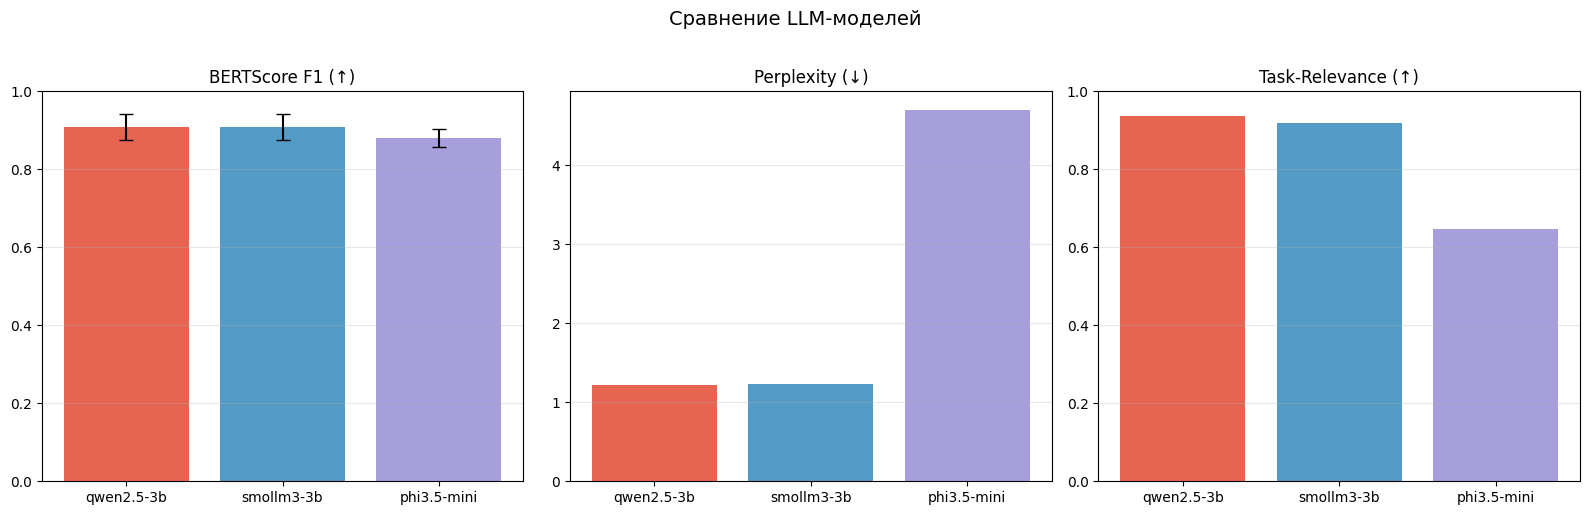

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
llm_names = [n for n in LLM_MODELS if n in all_predictions]
colors_llm = ["#E24A33", "#348ABD", "#988ED5"]

vals = [bertscore_results[n]["f1"] for n in llm_names if n in bertscore_results]
stds = [bertscore_results[n]["f1_std"] for n in llm_names if n in bertscore_results]
axes[0].bar(llm_names, vals, yerr=stds, color=colors_llm, alpha=0.85, capsize=5)
axes[0].set_title("BERTScore F1 (↑)"); axes[0].set_ylim(0, 1); axes[0].grid(axis="y", alpha=0.3)

ppl_names = [n for n in llm_names if n in perplexity_results]
ppl_vals = [perplexity_results[n]["perplexity"] for n in ppl_names]
ppl_colors = [colors_llm[llm_names.index(n)] for n in ppl_names]
axes[1].bar(ppl_names, ppl_vals, color=ppl_colors, alpha=0.85)
axes[1].set_title("Perplexity (↓)"); axes[1].grid(axis="y", alpha=0.3)

vals = [task_relevance_results[n]["composite"] for n in llm_names]
axes[2].bar(llm_names, vals, color=colors_llm, alpha=0.85)
axes[2].set_title("Task-Relevance (↑)"); axes[2].set_ylim(0, 1); axes[2].grid(axis="y", alpha=0.3)

plt.suptitle("Сравнение LLM-моделей", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("llm_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

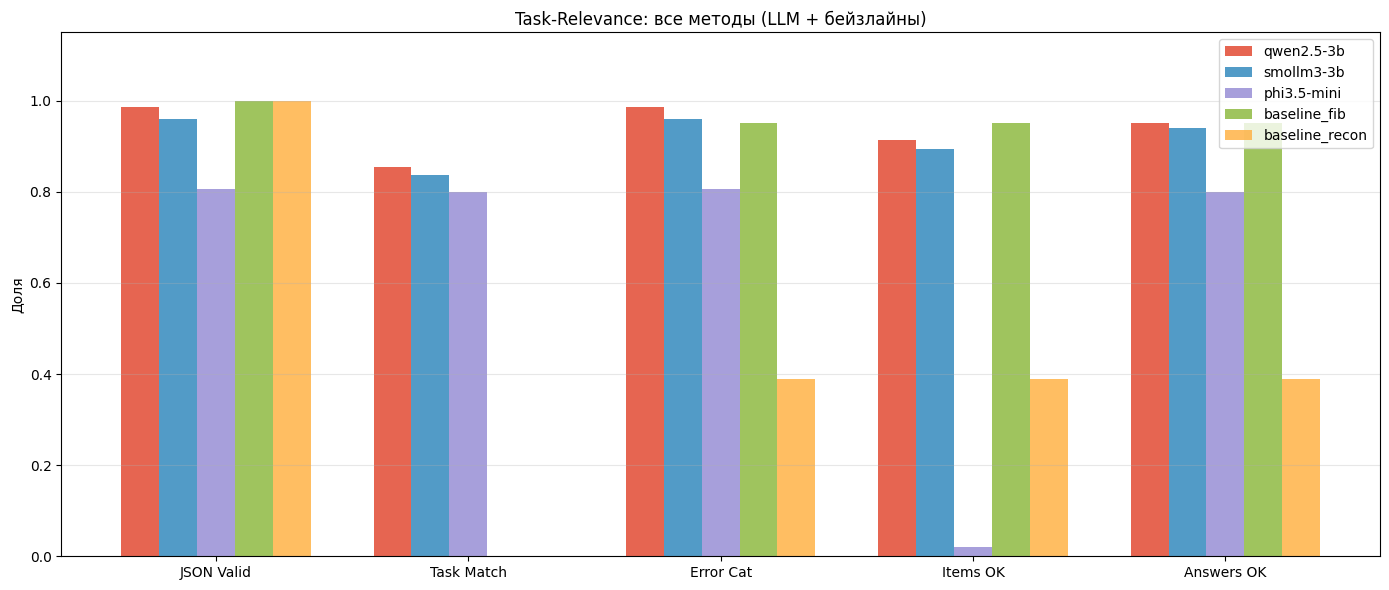

In [47]:
fig, ax = plt.subplots(figsize=(14, 6))
all_names = [n for n in ALL_METHODS if n in task_relevance_results]
metrics_keys = ["json_valid", "task_type_match", "error_cat_present", "items_count_ok", "has_answers"]
labels = ["JSON Valid", "Task Match", "Error Cat", "Items OK", "Answers OK"]

x = np.arange(len(labels))
width = 0.15
colors_all = ["#E24A33", "#348ABD", "#988ED5", "#8EBA42", "#FFB347"]

for i, name in enumerate(all_names):
    vals = [task_relevance_results[name][m] for m in metrics_keys]
    ax.bar(x + i * width, vals, width, label=name, color=colors_all[i], alpha=0.85)

ax.set_xticks(x + width * (len(all_names) - 1) / 2)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Доля")
ax.set_title("Task-Relevance: все методы (LLM + бейзлайны)")
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("all_methods_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

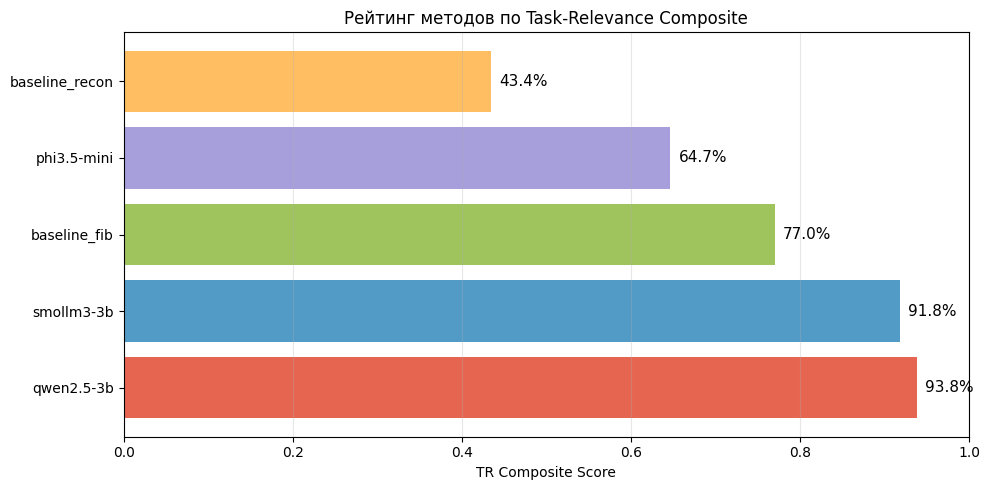

In [48]:
fig, ax = plt.subplots(figsize=(10, 5))
composites = {n: task_relevance_results[n]["composite"] for n in all_names}
sorted_methods = sorted(composites, key=composites.get, reverse=True)
vals = [composites[n] for n in sorted_methods]
colors_sorted = [colors_all[all_names.index(n)] for n in sorted_methods]

bars = ax.barh(sorted_methods, vals, color=colors_sorted, alpha=0.85)
ax.set_xlim(0, 1)
ax.set_xlabel("TR Composite Score")
ax.set_title("Рейтинг методов по Task-Relevance Composite")
ax.grid(axis="x", alpha=0.3)

for bar, val in zip(bars, vals):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"{val:.1%}", va='center', fontsize=11)

plt.tight_layout()
plt.savefig("methods_ranking.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Примеры генерации (все методы)

In [50]:
for name in all_names:
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    for i in [0, 1]:
        meta = val_meta_300[i]
        pred = all_predictions[name][i]
        print(f"\n--- Пример {i+1} ---")
        print(f"Задание: {meta['task_type']} | Ошибка: {meta['error_type']}")
        print(f"Source: {meta['source'][:80]}...")
        try:
            raw = pred.strip()
            if raw.startswith("```"):
                raw = raw.split("```")[1]
                if raw.startswith("json"): raw = raw[4:]
            parsed = json.loads(raw)
            items = parsed.get("task", {}).get("content_en", {}).get("items", [])
            print(f"Тип: {parsed.get('task', {}).get('type', 'N/A')} | Items: {len(items)}")
            if items:
                q = items[0].get('question_en', '')[:80]
                print(f"Item 1: {q}...")
        except:
            print(f"[Parse error] {pred[:100]}...")


  qwen2.5-3b

--- Пример 1 ---
Задание: vocabulary_fill | Ошибка: Preposition
Source: I live in a small town called Grycksbo and I've been part of Unga Kris volunteer...
Тип: vocabulary_fill | Items: 10
Item 1: I moved here last year and I’ve really enjoyed living in the ___ quiet countrysi...

--- Пример 2 ---
Задание: vocabulary_fill | Ошибка: Subject-Verb Agreement
Source: Science practically improve our lives....
Тип: vocabulary_fill | Items: 11
Item 1: I wanted to share some thoughts about how science ___ our daily lives in so many...

  smollm3-3b

--- Пример 1 ---
Задание: vocabulary_fill | Ошибка: Preposition
Source: I live in a small town called Grycksbo and I've been part of Unga Kris volunteer...
Тип: vocabulary_fill | Items: 15
Item 1: I ___ in a small town, and it's been a great experience to be involved in local ...

--- Пример 2 ---
Задание: vocabulary_fill | Ошибка: Subject-Verb Agreement
Source: Science practically improve our lives....
Тип: vocabulary_fill | Items: 1

## 12. Сохранение

In [51]:
report = {
    "date": datetime.now().isoformat(),
    "val_samples": 300,
    "methods": {},
}
for name in all_names:
    report["methods"][name] = {
        "type": "llm" if name in LLM_MODELS else "baseline",
        "bertscore": bertscore_results.get(name),
        "perplexity": perplexity_results.get(name),
        "task_relevance": task_relevance_results.get(name),
    }

with open("experiment_report_v2.json", "w", encoding="utf-8") as f:
    json.dump(report, f, ensure_ascii=False, indent=2)

print("✓ Сохранено:")
for f in ["all_predictions_v2.json", "model_comparison_v2.csv",
          "llm_comparison.png", "all_methods_comparison.png",
          "methods_ranking.png", "experiment_report_v2.json"]:
    print(f"  • {f}")

✓ Сохранено:
  • all_predictions_v2.json
  • model_comparison_v2.csv
  • llm_comparison.png
  • all_methods_comparison.png
  • methods_ranking.png
  • experiment_report_v2.json
